**Attention, le clustering étant une méthode de classification non supervisée, on ne peut vérifier qu'à posteriori de si les clusters trouvés correspondent bien à quelque chose au niveau des paramètres Prophet. S'il s'avère que les clusters qui vont résulter des différents types de clustering ne rendent pas bien compte de la réalité des choix nécessaires pour les paramètres Prophet, on passera à du supervisé (RandomForest par exemple, où on peut utiliser les paramètres qui doivent être choisis en divisant entre échantillon d'apprentissage et échantillon test pour mieux pourvoir prédire)**

In [21]:
# On importe les bibliothèques qui vont bien

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import seaborn as sns
import hdbscan
from sklearn.cluster import AgglomerativeClustering

In [22]:
# Import des données d'exécution précédente
series_temp_features = pd.read_excel("series_temp_features.xlsx")

print(series_temp_features.columns)

Index(['nom_serie', 'groupe_id', 'longueur_serie', 'mean_abs_diff',
       'std_normalise', 'std_normalise_first_half',
       'std_normalise_second_half', 'std_normalise_ecart', 'moyenne1',
       'moyenne2', 'ecart_moyennes_normalise', 'skewness', 'kurtosis',
       'moyenne_debut', 'moyenne_fin', 'ratio_debut_fin',
       'ecart_interquantile', 'autocorr', 'autocorrelation_saisonniere',
       'turning_points', 'mediane', 'tendance', 'adf_pvalue',
       'fft_dominant_freq', 'fft_dominant_amp', 'fft_dominant_phase',
       'shannon_entropy', 'mcmc_utilise', 'saisonnalite', 'mode_saisonnalite',
       'changepoint_prior_scale', 'rmsse', 'id_methode', 'surajustement'],
      dtype='object')


In [23]:
# Correction des NaN sinon le clustering ne peut pas fonctionner
i = 0
for colonne in series_temp_features.columns :
    for index, valeur in series_temp_features[colonne].items() :
        if pd.isna(valeur) :
            i += 1
            print(f"NaN trouvé dans la colonne '{colonne}', à l'index {index}")
print(f'Il y a {i} erreurs à corriger')

series_temp_features['std_normalise_first_half'] = series_temp_features['std_normalise_first_half'].fillna(0)
series_temp_features['std_normalise_second_half'] = series_temp_features['std_normalise_second_half'].fillna(0)
series_temp_features['std_normalise_ecart'] = series_temp_features['std_normalise_ecart'].fillna(abs(series_temp_features['std_normalise_first_half']-series_temp_features['std_normalise_second_half']))
series_temp_features = series_temp_features[series_temp_features.isnull().sum(axis=1) < 7]
series_temp_features['mode_saisonnalite'] = series_temp_features['mode_saisonnalite'].fillna('aucune')
series_temp_features['id_methode'] = series_temp_features['id_methode'].fillna('echec_total')
valeur_max = series_temp_features['ratio_debut_fin'].max(skipna=True)
series_temp_features['ratio_debut_fin'] = series_temp_features['ratio_debut_fin'].fillna(valeur_max + 1)

j = 0
for colonne in series_temp_features.columns :
    for index, valeur in series_temp_features[colonne].items() :
        if pd.isna(valeur) :
            j += 1
            print(f"NaN trouvé dans la colonne '{colonne}', à l'index {index}")
print(f'Il n\'y a plus que {j} erreurs à corriger (normalement c\'est 0)')

NaN trouvé dans la colonne 'std_normalise_first_half', à l'index 406
NaN trouvé dans la colonne 'std_normalise_first_half', à l'index 479
NaN trouvé dans la colonne 'std_normalise_first_half', à l'index 484
NaN trouvé dans la colonne 'std_normalise_second_half', à l'index 452
NaN trouvé dans la colonne 'std_normalise_ecart', à l'index 406
NaN trouvé dans la colonne 'std_normalise_ecart', à l'index 452
NaN trouvé dans la colonne 'std_normalise_ecart', à l'index 479
NaN trouvé dans la colonne 'std_normalise_ecart', à l'index 484
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 285
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 305
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 307
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 318
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 329
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 332
NaN trouvé dans la colonne 'ratio_debut_fin', à l'index 358
NaN trouvé dans la colonne 'ratio_debut_fin', à

In [24]:
# On extrait un tableau qui ne contient que les variables qui vont nous servir à prédire
features_input = series_temp_features.drop(columns=[
    'saisonnalite', 
    'mode_saisonnalite', 
    'mcmc_utilise', 
    'changepoint_prior_scale', 
    'id_methode', 
    'rmsse',
    'nom_serie'  # identifiant à garder à part si besoin
])

# Standardisation des données
features_standardisees = StandardScaler().fit_transform(features_input)

**Première méthode : clustering k-means**

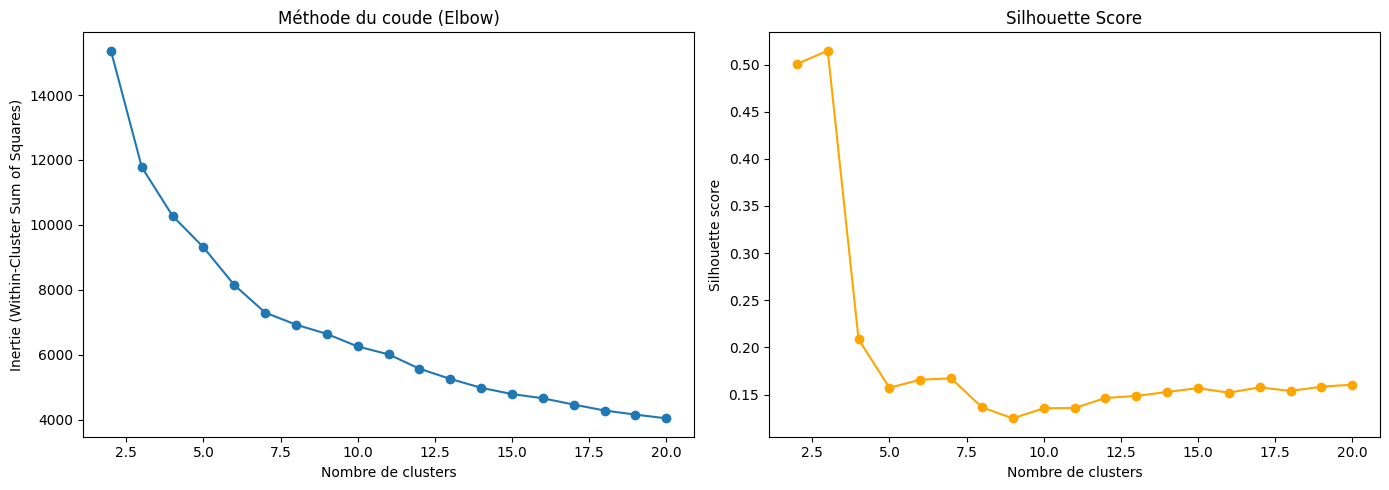

In [ ]:
range_n_clusters = range(2, 21)

silhouette_scores = []
inertias = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(features_standardisees)
    
    # Calcul inerties
    inertias.append(kmeans.inertia_)
    
    # Calcul du score
    score = silhouette_score(features_standardisees, cluster_labels)
    silhouette_scores.append(score)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Méthode du coude pour trouver le meilleur nombre de clusters
axs[0].plot(range_n_clusters, inertias, marker='o')
axs[0].set_title("Méthode du coude (Elbow)")
axs[0].set_xlabel("Nombre de clusters")
axs[0].set_ylabel("Inertie (Within-Cluster Sum of Squares)")

# Silhouette scores
axs[1].plot(range_n_clusters, silhouette_scores, marker='o', color='orange')
axs[1].set_title("Silhouette Score")
axs[1].set_xlabel("Nombre de clusters")
axs[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()


In [ ]:
# On refait le clustering avec le bon nombre de clusters (retenu par lecture graphique sur la méthode du coude)
n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(features_standardisees)

# On ajoute la colonne 'cluster' dans le df
series_temp_features['cluster'] = clusters

In [27]:
for cluster_id in range(n_clusters):
    subset = series_temp_features[series_temp_features['cluster'] == cluster_id]
    print(f"Cluster {cluster_id} :")
    print(f" - Nb séries : {len(subset)}")
    print(f" - % saisonnalité : {subset['saisonnalite'].mean()*100:.1f}%")
    print(f" - % additive : {(subset['mode_saisonnalite'] == 'additive').mean()*100:.1f}%")
    print(f" - % multiplicative : {(subset['mode_saisonnalite'] == 'multiplicative').mean()*100:.1f}%")
    print(f" - % MCMC utilisé : {subset['mcmc_utilise'].mean()*100:.1f}%")
    print(f" - changepoint_prior_scale moyen : {subset['changepoint_prior_scale'].mean():.3f}")
    print()

Cluster 0 :
 - Nb séries : 262
 - % saisonnalité : 51.5%
 - % additive : 17.2%
 - % multiplicative : 34.4%
 - % MCMC utilisé : 49.6%
 - changepoint_prior_scale moyen : 0.035

Cluster 1 :
 - Nb séries : 12
 - % saisonnalité : 41.7%
 - % additive : 8.3%
 - % multiplicative : 33.3%
 - % MCMC utilisé : 41.7%
 - changepoint_prior_scale moyen : 0.027

Cluster 2 :
 - Nb séries : 1
 - % saisonnalité : 100.0%
 - % additive : 0.0%
 - % multiplicative : 100.0%
 - % MCMC utilisé : 0.0%
 - changepoint_prior_scale moyen : 0.150

Cluster 3 :
 - Nb séries : 66
 - % saisonnalité : 54.5%
 - % additive : 24.2%
 - % multiplicative : 30.3%
 - % MCMC utilisé : 42.4%
 - changepoint_prior_scale moyen : 0.072

Cluster 4 :
 - Nb séries : 169
 - % saisonnalité : 67.5%
 - % additive : 24.9%
 - % multiplicative : 42.6%
 - % MCMC utilisé : 52.7%
 - changepoint_prior_scale moyen : 0.064

Cluster 5 :
 - Nb séries : 5
 - % saisonnalité : 100.0%
 - % additive : 40.0%
 - % multiplicative : 60.0%
 - % MCMC utilisé : 100.

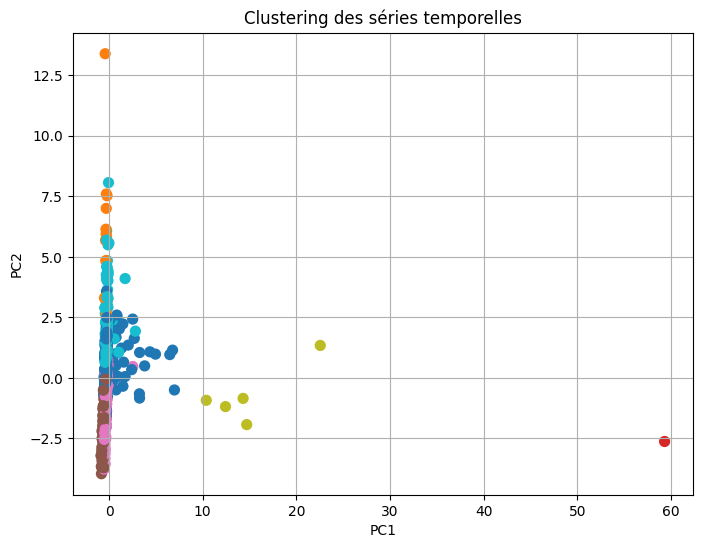

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_standardisees)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=50)
plt.title('Clustering des séries temporelles')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

**Bilan du clustering k-means : c'est archi nul les clusters ne se différencient pas vraiment, pas de profils typiques qui se distinguent, l'ACP est foireuse de toute façon...**

On ne va pas se faire violence, on ne va pas essayer de prédire avec ça, ce serait catastrophique.

**Deuxième méthode de clustering possible mais probablement mauvaise aussi pour la classification au vu de l'ACP : on va essayer un DBSCAN, qui va nous regrouper les séries temporelles par zones de plus forte densité**

Nombre de clusters trouvés : 3
Nombre de séries considérées comme outliers : 11

Cluster -1 :
 - Nb séries : 11
 - Ce cluster contient des outliers

Cluster 0 :
 - Nb séries : 9
 - saisonnalité : 22.2%
 - additive : 0.0%
 - multiplicative : 22.2%
 - MCMC utilisé : 22.2%
 - changepoint_prior_scale moyen : 0.032

Cluster 1 :
 - Nb séries : 23
 - saisonnalité : 60.9%
 - additive : 26.1%
 - multiplicative : 34.8%
 - MCMC utilisé : 60.9%
 - changepoint_prior_scale moyen : 0.150

Cluster 2 :
 - Nb séries : 566
 - saisonnalité : 56.5%
 - additive : 19.3%
 - multiplicative : 37.3%
 - MCMC utilisé : 49.1%
 - changepoint_prior_scale moyen : 0.045


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


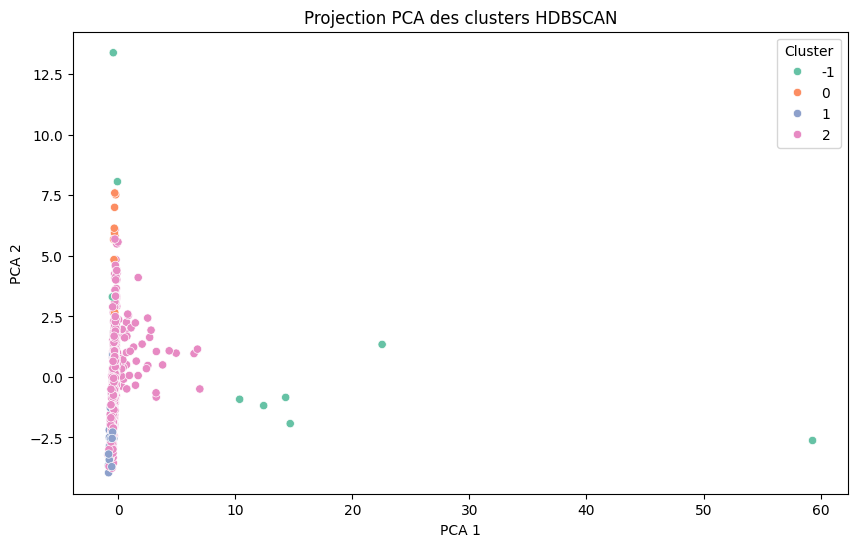

In [ ]:
# Clustering automatique
clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=3)
labels = clusterer.fit_predict(features_standardisees)

# On ajoute les clusters au DataFrame
series_temp_features['hdbscan_cluster'] = labels

# Résumé
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Nombre de séries considérées comme outliers : {n_outliers}")

# Stats par cluster
for cluster_id in sorted(set(labels)):
    subset = series_temp_features[series_temp_features['hdbscan_cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} :")
    print(f" - Nb séries : {len(subset)}")
    if cluster_id != -1:
        print(f" - saisonnalité : {100 * (subset['mode_saisonnalite'] != 'aucune').mean():.1f}%")
        print(f" - additive : {100 * (subset['mode_saisonnalite'] == 'additive').mean():.1f}%")
        print(f" - multiplicative : {100 * (subset['mode_saisonnalite'] == 'multiplicative').mean():.1f}%")
        print(f" - MCMC utilisé : {100 * subset['mcmc_utilise'].mean():.1f}%")
        print(f" - changepoint_prior_scale moyen : {subset['changepoint_prior_scale'].mean():.3f}")
    else:
        print(" - Ce cluster contient des outliers")

# Visualisation avec PCA comme toujours
pca = PCA(n_components=2)
proj = pca.fit_transform(features_standardisees)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=labels, palette='Set2', legend='full')
plt.title("Projection PCA des clusters HDBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.show()

**Comme on aurait pu s'y attendre, les résultats du clustering hdbsan sont catastrophiques : on trouve deux clusters max, et à la moindre modification du paramétrage on se retrouve avec plus de 80 clusters, bref ça n'a aucun sens.**

**Nouvelle tentative : agglomerative clustering**

Nombre de clusters trouvés : 8

Cluster 0 :
 - Nb séries : 72
 - saisonnalité : 59.7%
 - additive : 27.8%
 - multiplicative : 31.9%
 - MCMC utilisé : 48.6%
 - changepoint_prior_scale moyen : 0.088

Cluster 1 :
 - Nb séries : 12
 - saisonnalité : 41.7%
 - additive : 8.3%
 - multiplicative : 33.3%
 - MCMC utilisé : 41.7%
 - changepoint_prior_scale moyen : 0.027

Cluster 2 :
 - Nb séries : 257
 - saisonnalité : 49.8%
 - additive : 15.6%
 - multiplicative : 34.2%
 - MCMC utilisé : 46.7%
 - changepoint_prior_scale moyen : 0.036

Cluster 3 :
 - Nb séries : 39
 - saisonnalité : 59.0%
 - additive : 17.9%
 - multiplicative : 41.0%
 - MCMC utilisé : 59.0%
 - changepoint_prior_scale moyen : 0.027

Cluster 4 :
 - Nb séries : 5
 - saisonnalité : 100.0%
 - additive : 40.0%
 - multiplicative : 60.0%
 - MCMC utilisé : 100.0%
 - changepoint_prior_scale moyen : 0.030

Cluster 5 :
 - Nb séries : 209
 - saisonnalité : 63.6%
 - additive : 21.5%
 - multiplicative : 42.1%
 - MCMC utilisé : 51.2%
 - changepoi

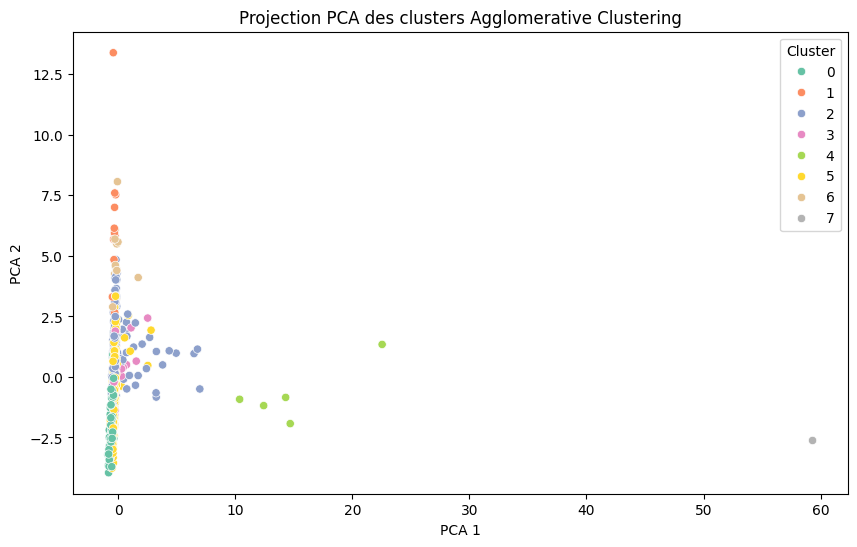

In [ ]:
# Choix du nombre de clusters, ici arbitrairement 8
n_clusters = 8

agglo = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward' # 'ward' = minimisation de variance intra-cluster
)

labels = agglo.fit_predict(features_standardisees)

series_temp_features['agglo_cluster'] = labels

# Résumé
print(f"Nombre de clusters trouvés : {n_clusters}")
for cluster_id in sorted(set(labels)):
    subset = series_temp_features[series_temp_features['agglo_cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} :")
    print(f" - Nb séries : {len(subset)}")
    print(f" - saisonnalité : {100 * (subset['mode_saisonnalite'] != 'aucune').mean():.1f}%")
    print(f" - additive : {100 * (subset['mode_saisonnalite'] == 'additive').mean():.1f}%")
    print(f" - multiplicative : {100 * (subset['mode_saisonnalite'] == 'multiplicative').mean():.1f}%")
    print(f" - MCMC utilisé : {100 * subset['mcmc_utilise'].mean():.1f}%")
    print(f" - changepoint_prior_scale moyen : {subset['changepoint_prior_scale'].mean():.3f}")

# PCA pour visualiser
pca = PCA(n_components=2)
proj = pca.fit_transform(features_standardisees)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=labels, palette='Set2', legend='full')
plt.title("Projection PCA des clusters Agglomerative Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.show()

**Définitivement archi nul : on va passer à du RandomForest ou GradientBoosting.**

J'aurais pas dû faire ça, le clustering c'était une perte de temps. Heureusement les features récoltées en amont serviront aussi pour la régression supervisée. (voir notebook suivant)